# PRÁCTICA: CLASIFICACIÓN DE NOTICIAS DEPORTIVAS
# Dataset: AG News | Categoría: Sports
# Basado en los PDFs de Extracción, Training/Test y Evaluación

## 1. INSTALACIÓN E IMPORTACIÓN DE DEPENDENCIAS

In [1]:
# Instalar la biblioteca datasets de Hugging Face
!pip install -q datasets

# Importar las herramientas necesarias
from datasets import load_dataset, concatenate_datasets
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    accuracy_score, f1_score, roc_curve, roc_auc_score
)

print("Dependencias cargadas correctamente.")

Dependencias cargadas correctamente.


## 2. CARGA DEL DATASET AG NEWS

AG News tiene 4 categorías: World(0), Sports(1), Business(2), Sci/Tech(3)
NUESTRA CLASE POSITIVA: Sports (label = 1)

In [2]:
print("Cargando dataset AG News...")
ag_news = load_dataset("ag_news")

print(f"Estructura: {ag_news}")
print(f"Train size: {len(ag_news['train'])}")
print(f"Test size: {len(ag_news['test'])}")

Cargando dataset AG News...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Estructura: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Train size: 120000
Test size: 7600


## 3. CONVERSIÓN A CLASIFICACIÓN BINARIA

Convertimos 4 clases → 2 clases: Sports(1) vs No-Sports(0)

In [ ]:
# Función para convertir etiquetas a binario
def convertir_a_binario(elemento):
    return {"label": 1 if elemento["label"] == 1 else 0}

# Aplicar conversión y fusionar train + test
ag_news_binario = ag_news.map(convertir_a_binario)

full_dataset = concatenate_datasets([
    ag_news_binario["train"],
    ag_news_binario["test"]
])

print(f"Total corpus: {len(full_dataset)}")

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Total corpus: 127600


## 4. DIVISIÓN EN TRAIN / DEV / TEST

Metodología del PDF: 80% Train, 10% Dev, 10% Test con shuffle

In [4]:
SEMILLA = 42

# Primera división: 80% train, 20% temp
division_1 = full_dataset.train_test_split(test_size=0.2, seed=SEMILLA, shuffle=True)
train_set = division_1["train"]
temp_set  = division_1["test"]

# Segunda división: temp → 10% dev + 10% test
division_2 = temp_set.train_test_split(test_size=0.5, seed=SEMILLA, shuffle=True)
dev_set  = division_2["train"]
test_set = division_2["test"]

print(f"Train: {len(train_set)} | Dev: {len(dev_set)} | Test: {len(test_set)}")

Train: 102080 | Dev: 12760 | Test: 12760


## 5. VERIFICACIÓN DE LA DIVISIÓN

In [5]:
# Contar clases en cada conjunto
def contar_clases(dataset):
    pos = sum(1 for item in dataset if item["label"] == 1)
    neg = len(dataset) - pos
    return pos, neg

train_pos, train_neg = contar_clases(train_set)
dev_pos, dev_neg = contar_clases(dev_set)
test_pos, test_neg = contar_clases(test_set)

print(f"Train: Sports={train_pos} ({train_pos/len(train_set)*100:.1f}%), No-Sports={train_neg}")
print(f"Dev:   Sports={dev_pos} ({dev_pos/len(dev_set)*100:.1f}%), No-Sports={dev_neg}")
print(f"Test:  Sports={test_pos} ({test_pos/len(test_set)*100:.1f}%), No-Sports={test_neg}")

Train: Sports=25452 (24.9%), No-Sports=76628
Dev:   Sports=3189 (25.0%), No-Sports=9571
Test:  Sports=3259 (25.5%), No-Sports=9501


## 6. LEXICONS PARA EXTRACCIÓN DE CARACTERÍSTICAS

In [6]:
# Palabras relacionadas con deportes
sports_lexicon = {
    'goal', 'stadium', 'match', 'player', 'players', 'team', 'teams',
    'coach', 'league', 'champion', 'championship', 'score', 'scored',
    'win', 'winner', 'winning', 'tournament', 'olympics', 'football',
    'soccer', 'basketball', 'tennis', 'golf', 'baseball', 'hockey',
    'game', 'games', 'race', 'cup', 'final', 'season', 'record'
}

# Palabras que indican NO es deportivo
non_sports_lexicon = {
    'government', 'stock', 'market', 'election', 'policy', 'economy',
    'technology', 'science', 'research', 'company', 'percent', 'growth',
    'president', 'minister', 'law', 'court', 'vote', 'bill'
}

# Palabras de énfasis emocional
emphasis_lexicon = {
    'win', 'lose', 'won', 'lost', 'victory', 'defeat', 'amazing',
    'incredible', 'surprise', 'shock', 'stunning', 'historic'
}

pronouns = {'i', 'me', 'my', 'we', 'us', 'our', 'you', 'your'}

print(f"Lexicons: Sports={len(sports_lexicon)}, Non-Sports={len(non_sports_lexicon)}")

Lexicons: Sports=32, Non-Sports=18


## 7. FUNCIÓN DE EXTRACCIÓN DE CARACTERÍSTICAS

In [7]:
def extract_features(texto):
    """
    Convierte texto en vector de 6 características:
    x1: palabras deportivas
    x2: palabras no-deportivas
    x3: palabras de énfasis
    x4: pronombres
    x5: presencia de '!'
    x6: log(longitud)
    """
    tokens = texto.lower().split()
    longitud = len(tokens) if len(tokens) > 0 else 1

    x1 = sum(1 for w in tokens if w in sports_lexicon)
    x2 = sum(1 for w in tokens if w in non_sports_lexicon)
    x3 = sum(1 for w in tokens if w in emphasis_lexicon)
    x4 = sum(1 for w in tokens if w in pronouns)
    x5 = 1 if "!" in texto else 0
    x6 = math.log(longitud)

    return np.array([x1, x2, x3, x4, x5, x6])

# Probar
ejemplo = train_set[0]["text"]
print(f"Ejemplo: {ejemplo[:100]}...")
print(f"Features: {extract_features(ejemplo)}")

Ejemplo: Rockwell Collins Sees 2005 EPS Up 17 Pct Electronics manufacturer Rockwell Collins Inc. (COL.N: Quot...
Features: [0.         0.         0.         0.         0.         3.55534806]


## 8. CREAR MATRICES DE FEATURES

In [8]:
print("Extrayendo características...")

X_train = np.array([extract_features(item["text"]) for item in train_set])
X_dev   = np.array([extract_features(item["text"]) for item in dev_set])
X_test  = np.array([extract_features(item["text"]) for item in test_set])

y_train = np.array([item["label"] for item in train_set])
y_dev   = np.array([item["label"] for item in dev_set])
y_test  = np.array([item["label"] for item in test_set])

print(f"X_train: {X_train.shape}, X_dev: {X_dev.shape}, X_test: {X_test.shape}")

Extrayendo características...
X_train: (102080, 6), X_dev: (12760, 6), X_test: (12760, 6)


## 9. NORMALIZACIÓN

¡CRUCIAL! fit() SOLO en Train para evitar Data Leakage

In [9]:
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0) + 1e-8

X_train_norm = (X_train - train_mean) / train_std
X_dev_norm   = (X_dev   - train_mean) / train_std
X_test_norm  = (X_test  - train_mean) / train_std

print(f"Normalización aplicada. Media train: ~0")
print(f"{X_train_norm.mean(axis=0)}")

Normalización aplicada. Media train: ~0
[ 3.90387935e-15 -2.19632306e-15 -3.50820905e-15  5.03808833e-16
 -8.60487284e-16  2.72426097e-12]


## 10. VISUALIZACIÓN DE FEATURES

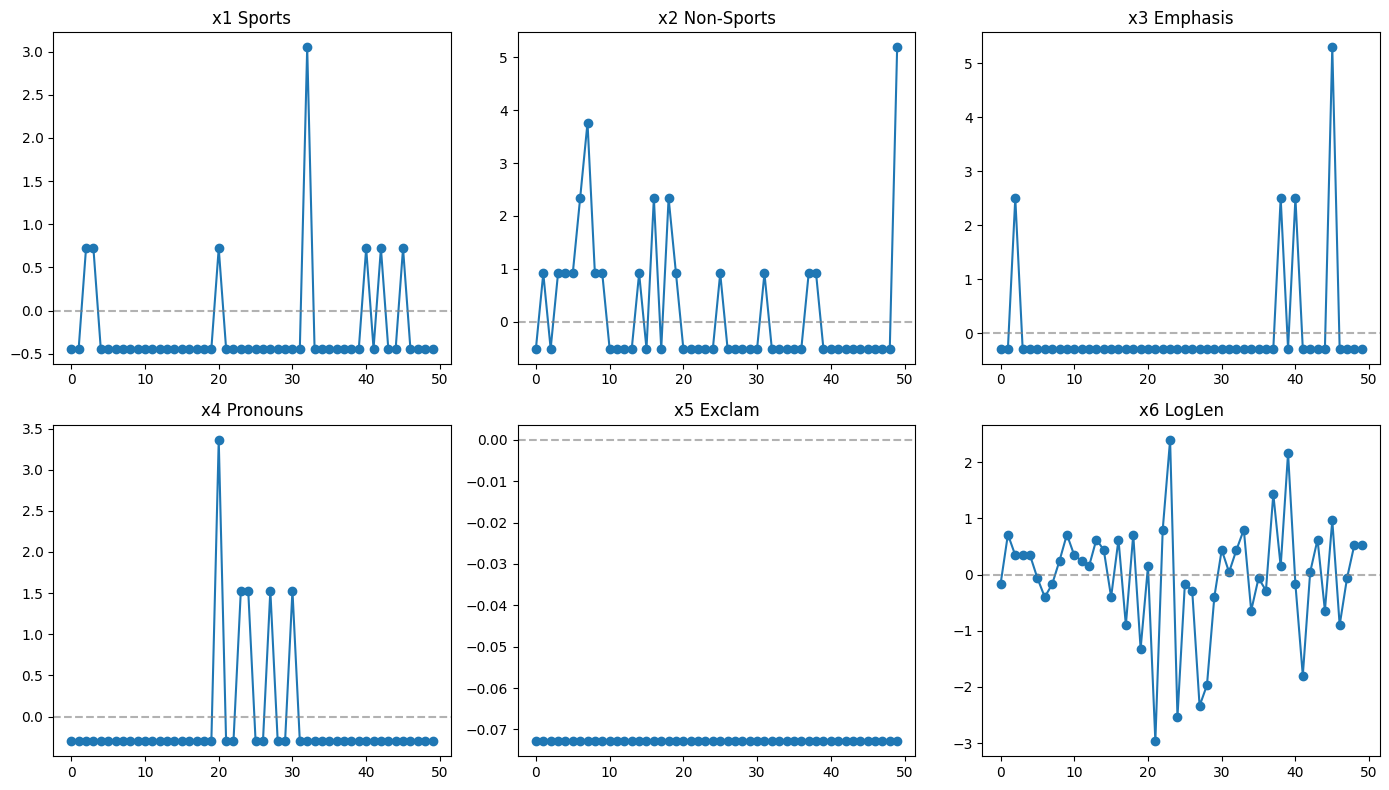

In [10]:
feature_names = ['x1 Sports', 'x2 Non-Sports', 'x3 Emphasis', 
                 'x4 Pronouns', 'x5 Exclam', 'x6 LogLen']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for idx, ax in enumerate(axes.flatten()):
    ax.plot(X_train_norm[:50, idx], marker='o')
    ax.axhline(0, linestyle='--', color='gray', alpha=0.6)
    ax.set_title(feature_names[idx])
plt.tight_layout()
plt.show()

## 11. MODELO: REGRESIÓN LOGÍSTICA

In [11]:
def sigmoid(z):
    """Función sigmoide: z → probabilidad (0,1)"""
    return 1 / (1 + np.exp(-z))

def predecir(X, theta):
    """Clasifica: si prob >= 0.5 → Sports (1), else → No-Sports (0)"""
    return (sigmoid(X @ theta) >= 0.5).astype(int)

print("Modelo de Regresión Logística definido.")

Modelo de Regresión Logística definido.


## 12. ENTRENAMIENTO CON DESCENSO DE GRADIENTE

In [12]:
# Hiperparámetros
ETA = 0.1       # Learning rate
EPOCHS = 20     # Número de épocas

n_features = X_train_norm.shape[1]
theta = np.zeros(n_features)  # Pesos inicializados en 0

loss_history = []
theta_history = []

print(f"Entrenando con η={ETA}, épocas={EPOCHS}...")

for epoch in range(EPOCHS):
    total_loss = 0.0
    
    for x_i, y_i in zip(X_train_norm, y_train):
        # Forward pass
        z = np.dot(theta, x_i)
        y_hat = sigmoid(z)
        
        # Calcular pérdida (Cross-Entropy)
        loss = -(y_i * np.log(y_hat + 1e-8) + (1 - y_i) * np.log(1 - y_hat + 1e-8))
        total_loss += loss
        
        # Backward pass: actualizar pesos
        error = y_i - y_hat
        theta += ETA * error * x_i
    
    avg_loss = total_loss / len(X_train_norm)
    loss_history.append(avg_loss)
    theta_history.append(theta.copy())
    
    if (epoch + 1) % 5 == 0:
        print(f"Época {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")

print("Entrenamiento completado.")
theta_history = np.array(theta_history)

Entrenando con η=0.1, épocas=20...
Época 5/20 | Loss: 0.501834
Época 10/20 | Loss: 0.501834
Época 15/20 | Loss: 0.501834
Época 20/20 | Loss: 0.501834
Entrenamiento completado.


## 13. GRÁFICAS DE ENTRENAMIENTO

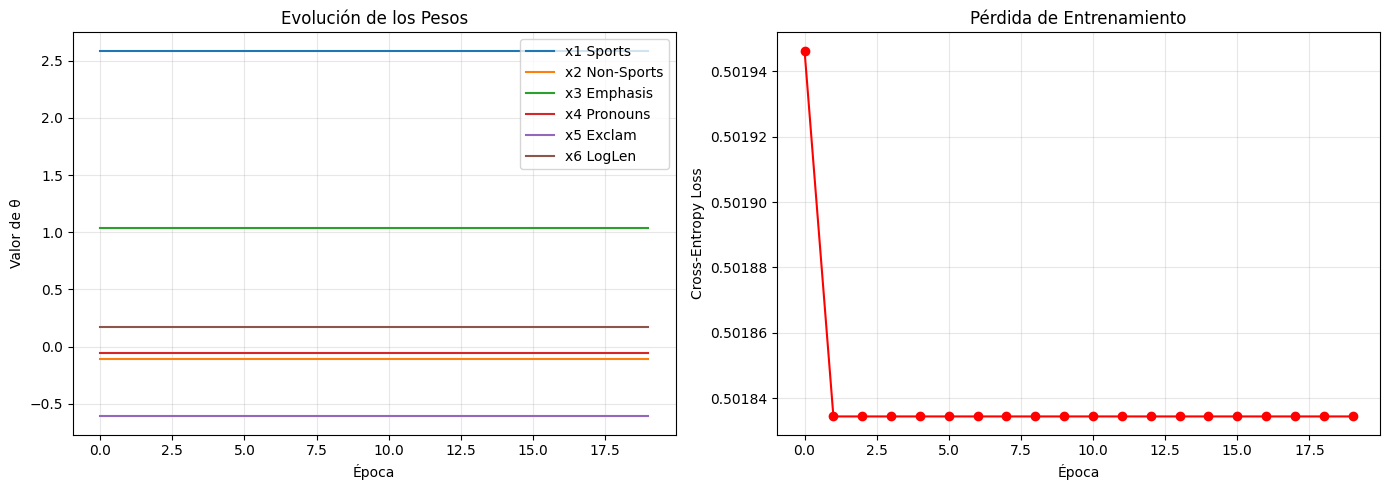

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Evolución de pesos
for j in range(n_features):
    axes[0].plot(theta_history[:, j], label=feature_names[j])
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Valor de θ")
axes[0].set_title("Evolución de los Pesos")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Pérdida
axes[1].plot(loss_history, marker='o', color='red')
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Cross-Entropy Loss")
axes[1].set_title("Pérdida de Entrenamiento")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 14. EVALUACIÓN EN DEV SET

In [14]:
y_dev_pred = predecir(X_dev_norm, theta)
cm_dev = confusion_matrix(y_dev, y_dev_pred)

precision_dev = precision_score(y_dev, y_dev_pred)
recall_dev = recall_score(y_dev, y_dev_pred)
f1_dev = f1_score(y_dev, y_dev_pred)
accuracy_dev = accuracy_score(y_dev, y_dev_pred)

print("=== EVALUACIÓN EN DEV SET ===")
print(f"\nMatriz de Confusión:\n{cm_dev}")
print(f"\nAccuracy:   {accuracy_dev:.4f}")
print(f"Precision:  {precision_dev:.4f}")
print(f"Recall:     {recall_dev:.4f}")
print(f"F1-Score:   {f1_dev:.4f}")

=== EVALUACIÓN EN DEV SET ===

Matriz de Confusión:
[[8636  935]
 [ 950 2239]]

Accuracy:   0.8523
Precision:  0.7054
Recall:     0.7021
F1-Score:   0.7038


## 15. EVALUACIÓN FINAL EN TEST SET

In [15]:
y_test_pred = predecir(X_test_norm, theta)
cm_test = confusion_matrix(y_test, y_test_pred)

precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

print("=== EVALUACIÓN FINAL EN TEST SET ===")
print(f"\nMatriz de Confusión:\n{cm_test}")
print(f"\nAccuracy:   {accuracy_test:.4f} ({accuracy_test*100:.2f}%)")
print(f"Precision:  {precision_test:.4f} ({precision_test*100:.2f}%)")
print(f"Recall:     {recall_test:.4f} ({recall_test*100:.2f}%)")
print(f"F1-Score:   {f1_test:.4f} ({f1_test*100:.2f}%)")

=== EVALUACIÓN FINAL EN TEST SET ===

Matriz de Confusión:
[[8501 1000]
 [1029 2230]]

Accuracy:   0.8410 (84.10%)
Precision:  0.6904 (69.04%)
Recall:     0.6843 (68.43%)
F1-Score:   0.6873 (68.73%)


## 16. CURVA ROC Y AUC

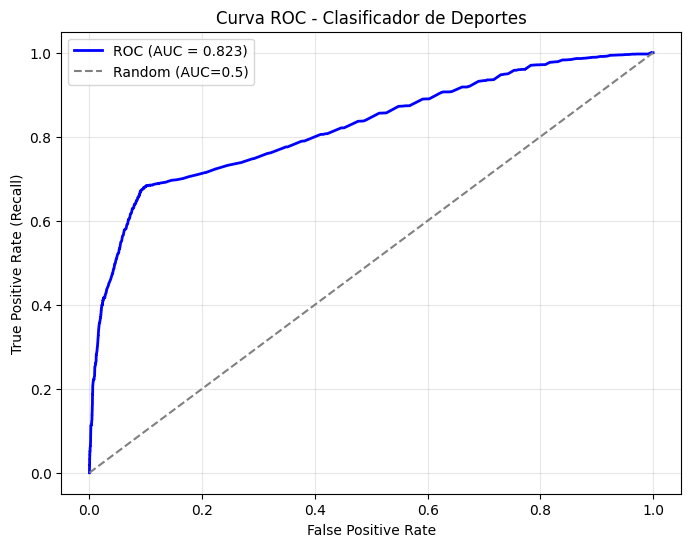


AUC Score: 0.8231


In [16]:
# Obtener probabilidades para la curva ROC
y_test_probs = sigmoid(X_test_norm @ theta)

fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
auc_score = roc_auc_score(y_test, y_test_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curva ROC - Clasificador de Deportes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nAUC Score: {auc_score:.4f}")

## 17. COMPARACIÓN DEV vs TEST (Detectar Overfitting)

In [17]:
print("=== COMPARACIÓN DEV vs TEST ===")
print(f"{'Métrica':<12} {'Dev':<12} {'Test':<12}")
print("-" * 36)
print(f"{'Accuracy':<12} {accuracy_dev:<12.4f} {accuracy_test:<12.4f}")
print(f"{'F1-Score':<12} {f1_dev:<12.4f} {f1_test:<12.4f}")

diff = abs(f1_dev - f1_test)
if diff > 0.05:
    print(f"\n⚠️ Posible overfitting (diferencia F1: {diff:.4f})")
else:
    print(f"\n✓ El modelo generaliza bien (diferencia F1: {diff:.4f})")

=== COMPARACIÓN DEV vs TEST ===
Métrica      Dev          Test        
------------------------------------
Accuracy     0.8523       0.8410      
F1-Score     0.7038       0.6873      

✓ El modelo generaliza bien (diferencia F1: 0.0164)


## 18. PRUEBA CON NUEVOS EJEMPLOS

In [18]:
ejemplos = [
    "The football team won the championship in a stunning overtime victory.",
    "Stock markets fell today following new economic policy announcements.",
    "Tennis star advances to the final round after hard fought match.",
    "Technology company released quarterly earnings with record profits."
]

for i, texto in enumerate(ejemplos):
    features = extract_features(texto)
    features_norm = (features - train_mean) / train_std
    prob = sigmoid(np.dot(theta, features_norm))
    pred = "DEPORTES" if prob >= 0.5 else "NO DEPORTES"
    print(f"\n{i+1}. '{texto[:50]}...'")
    print(f"   Prob: {prob:.4f} → {pred}")


1. 'The football team won the championship in a stunni...'
   Prob: 1.0000 → DEPORTES

2. 'Stock markets fell today following new economic po...'
   Prob: 0.0726 → NO DEPORTES

3. 'Tennis star advances to the final round after hard...'
   Prob: 0.9806 → DEPORTES

4. 'Technology company released quarterly earnings wit...'
   Prob: 0.5955 → DEPORTES


## 19. RESUMEN FINAL

In [19]:
print("="*60)
print("RESUMEN DEL ENTRENAMIENTO")
print("="*60)
print(f"Dataset: AG News → Sports vs No-Sports")
print(f"Total: {len(full_dataset)} | Train: {len(train_set)} | Dev: {len(dev_set)} | Test: {len(test_set)}")
print(f"Features: {n_features} | η={ETA} | épocas={EPOCHS}")
print(f"\nPESOS FINALES: {np.round(theta, 4)}")
print(f"\nRESULTADOS TEST:")
print(f"  Accuracy:  {accuracy_test:.4f}")
print(f"  F1-Score:  {f1_test:.4f}")
print(f"  AUC:       {auc_score:.4f}")
print("="*60)

RESUMEN DEL ENTRENAMIENTO
Dataset: AG News → Sports vs No-Sports
Total: 127600 | Train: 102080 | Dev: 12760 | Test: 12760
Features: 6 | η=0.1 | épocas=20

PESOS FINALES: [ 2.5884 -0.1116  1.0344 -0.0533 -0.6101  0.1678]

RESULTADOS TEST:
  Accuracy:  0.8410
  F1-Score:  0.6873
  AUC:       0.8231
